<a href="https://colab.research.google.com/github/abdurrahman16/Electricity-Demand-Forecasting_Model-XGboost-/blob/main/Electricity_Demand_Forecasting_Model(XGboost).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #bar graph
%matplotlib inline
import seaborn as sns #visualization
import random #random values

In [5]:
data=pd.read_csv('Electricity_Dataset.csv') #file import
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [6]:
data.info() #data information check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [7]:
data['Timestamp']= pd.to_datetime(data['Timestamp']) #timestamp object to datetime


/tmp/ipython-input-4002922567.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Timestamp']= pd.to_datetime(data['Timestamp']) #timestamp object to datetime


In [8]:
data = data.set_index('Timestamp') #timestamp set as index

In [9]:
data[['Temperature','Humidity','Demand']].describe() #check the information on some columns

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [10]:
#check missing values
data.isnull().sum()


,0
hour,11
dayofweek,9
month,8
year,5
dayofyear,5
Temperature,7
Humidity,10
Demand,7


In [11]:
#check where all the nun values are available
data[data.isnull().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [12]:
data[data.isnull().all(axis=1)] #find all the rows having null value

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
#drop fully missing line
data=data.dropna(how='all')
#data[data.isnull().all(axis=1)]


In [17]:
#use backward fill bfill or forward fill ffill || Dat Time index thakle(timeseries hole interpolate()) method use kora jabe

data[['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'Temperature', 'Humidity', 'Demand']]=data[['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'Temperature', 'Humidity', 'Demand']].ffill()

In [18]:
data.shape #check row column
data.insert(5,'quarter',data.index.quarter) #insert quarter column
data


,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [19]:
data[['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'Temperature', 'Humidity', 'Demand']]=data[['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'Temperature', 'Humidity', 'Demand']].astype(int)
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3,61,2457
2020-01-01,1,2,1,2020,1,1,3,52,2269
2020-01-01,2,2,1,2020,1,1,4,36,2215
2020-01-01,3,2,1,2020,1,1,3,72,2174
2020-01-01,4,2,1,2020,1,1,3,90,2472
...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,4,3,43,4689
2024-12-31,20,1,12,2024,366,4,3,51,4331
2024-12-31,21,1,12,2024,366,4,3,40,4015


In [20]:
#create week column
data.insert(5,'weekofyear',data.index.isocalendar().week.astype(int))

In [21]:
#given date is weekend or not
data.insert(7,'is_weekend', data.index.dayofweek.isin([5,6]).astype(int))
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3,61,2457
2020-01-01,1,2,1,2020,1,1,1,0,3,52,2269
2020-01-01,2,2,1,2020,1,1,1,0,4,36,2215
2020-01-01,3,2,1,2020,1,1,1,0,3,72,2174
2020-01-01,4,2,1,2020,1,1,1,0,3,90,2472
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3,43,4689
2024-12-31,20,1,12,2024,366,1,4,0,3,51,4331
2024-12-31,21,1,12,2024,366,1,4,0,3,40,4015


In [22]:
import holidays
data['Holidays']=holidays.BD(years=data.year)


In [34]:
data.drop('Holidays',axis=1)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3,61,2457,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3,52,2269,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4,36,2215,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3,72,2174,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3,90,2472,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3,43,4689,5102.0,5105.0
2024-12-31,20,1,12,2024,366,1,4,0,3,51,4331,4187.0,4673.0
2024-12-31,21,1,12,2024,366,1,4,0,3,40,4015,3859.0,3856.0


In [31]:
#lagged features
data['Demand_lag_24hr']= data['Demand'].shift(24)

In [32]:
data['demand_lag_168hr']=data['Demand'].shift(168)

In [35]:
data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holidays,Demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14,37,4587,NaN,4733.0,NaN
2020-01-07,17,1,1,2020,7,2,1,0,6,54,4833,NaN,4796.0,NaN
2020-01-07,18,1,1,2020,7,2,1,0,17,49,5400,NaN,4791.0,NaN
2020-01-07,19,1,1,2020,7,2,1,0,3,37,4424,NaN,4492.0,NaN
2020-01-07,20,1,1,2020,7,2,1,0,7,46,4279,NaN,4398.0,NaN
2020-01-07,21,1,1,2020,7,2,1,0,5,44,3768,NaN,3705.0,NaN
2020-01-07,22,1,1,2020,7,2,1,0,3,46,2924,NaN,3211.0,NaN
2020-01-07,23,1,1,2020,7,2,1,0,3,44,2657,NaN,2857.0,NaN
2020-01-08,0,2,1,2020,8,2,1,0,3,47,2363,NaN,2216.0,2457.0


In [38]:
#rolling statistics
data['demand_rolling_mean_24hr']= data['Demand'].rolling(window=24).mean()

In [41]:
data['demand_rolling_std_24hr']= data['Demand'].rolling(window=24).std()

In [43]:
data.dropna()

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holidays,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,,
2020-02-21,0,4,2,2020,52,8,1,0,7,45,2815,International Mother's language Day,2676.0,2724.0,4301.500000,1064.712984
2020-02-21,1,4,2,2020,52,8,1,0,9,39,2801,International Mother's language Day,2591.0,2532.0,4310.250000,1050.816835
2020-02-21,2,4,2,2020,52,8,1,0,5,50,2187,International Mother's language Day,2539.0,2256.0,4295.583333,1078.700302
2020-02-21,3,4,2,2020,52,8,1,0,9,59,2505,International Mother's language Day,2348.0,2685.0,4302.125000,1066.786125
2020-02-21,4,4,2,2020,52,8,1,0,7,56,2615,International Mother's language Day,2865.0,2933.0,4291.708333,1082.533441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-16,19,0,12,2024,351,51,4,0,3,56,4760,Victory Day,4170.0,5085.0,4032.125000,1086.774858
2024-12-16,20,0,12,2024,351,51,4,0,5,69,4514,Victory Day,3836.0,4415.0,4060.375000,1090.261549
2024-12-16,21,0,12,2024,351,51,4,0,3,67,3906,Victory Day,3604.0,4365.0,4072.958333,1086.501545


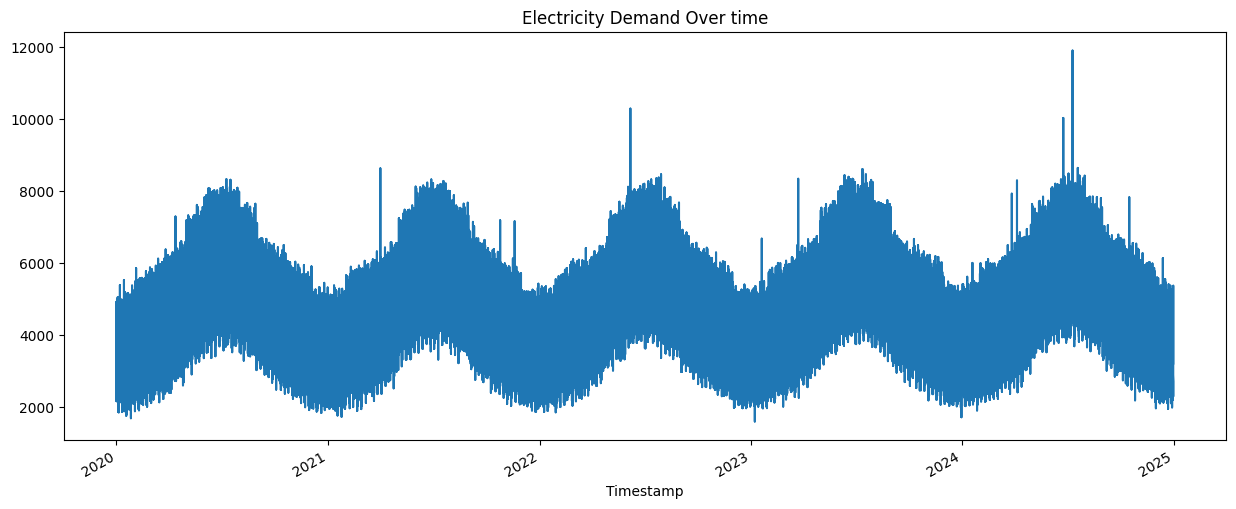

In [44]:
data['Demand'].plot(figsize=(15,6), title='Electricity Demand Over time')
plt.show()

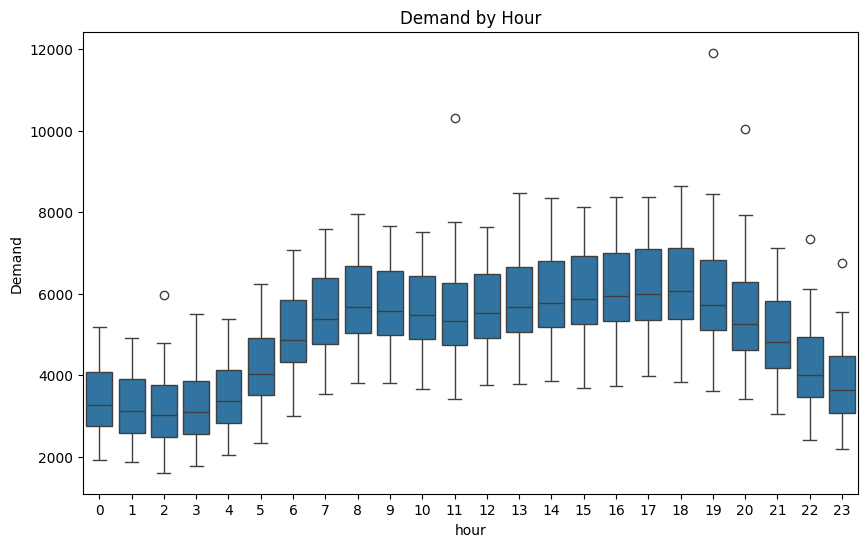

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(data= data, x='hour', y='Demand')
plt.title('Demand by Hour');


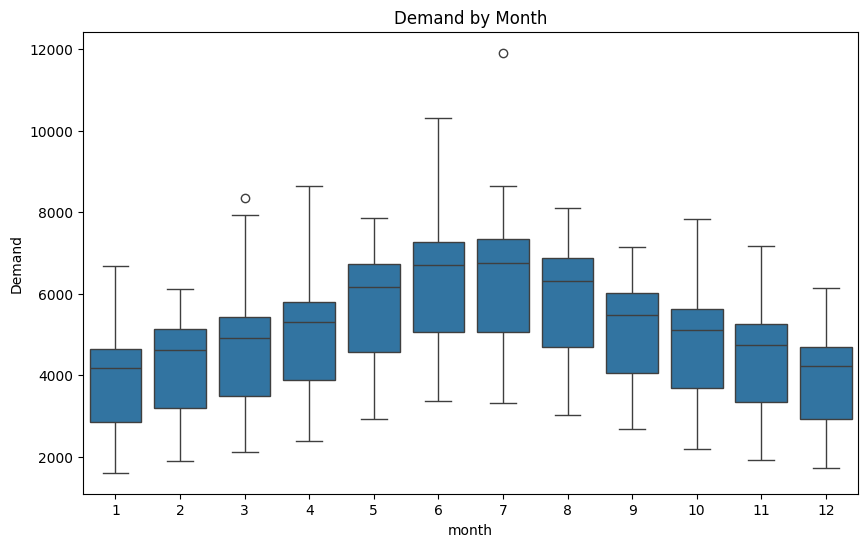

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data= data, x='month', y='Demand')
plt.title('Demand by Month');

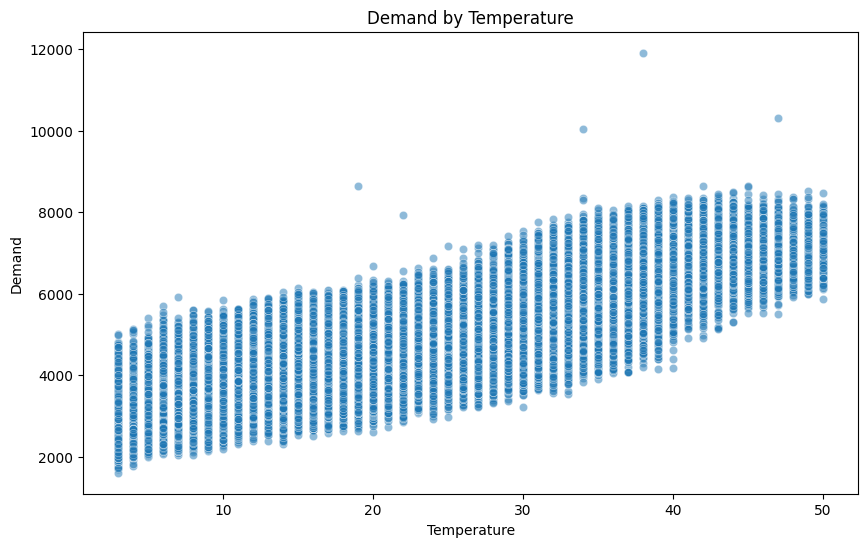

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(data= data, x='Temperature', y='Demand', alpha=0.5)
plt.title('Demand by Temperature');

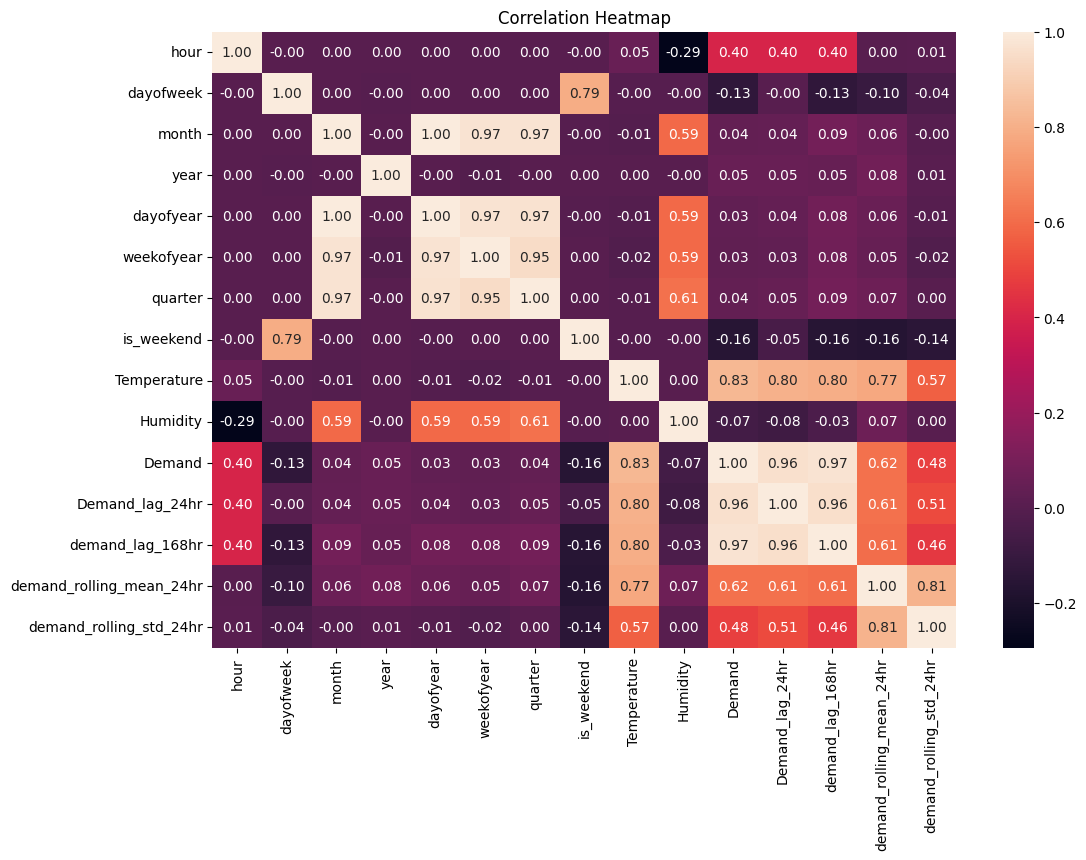

In [57]:
#data = data.drop('Holidays',axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap');
plt.show()

In [60]:
Y= data.Demand

In [62]:
X= data.drop('Demand', axis=1)

In [63]:
X

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3,61,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3,52,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4,36,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3,72,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3,90,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3,43,5102.0,5105.0,4039.500000,976.936294
2024-12-31,20,1,12,2024,366,1,4,0,3,51,4187.0,4673.0,4045.500000,978.322788
2024-12-31,21,1,12,2024,366,1,4,0,3,40,3859.0,3856.0,4052.000000,977.547730


In [74]:
#training and testing
X_train =X.loc[: "2023-12-31"]

In [85]:
Y_train = Y.loc[: "2023-12-31"]

In [76]:
x_test= X.loc['2024-01-01': ]

In [78]:
Y_test= Y.loc['2024-01-01':]

In [79]:
print(X_train.shape)
print(Y_train.shape)
print(x_test.shape)
print(Y_test.shape)

(35060, 14)
(8808,)
(8784, 14)
(8784,)


In [80]:
from xgboost import XGBRegressor


In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [83]:
model_xgb =XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01,random_state=42,
                        objective='reg:squarederror')

In [86]:
model_xgb.fit(X_train, Y_train, eval_set=[(X_train, Y_train),(x_test, Y_test)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [89]:
predictions_xgb = model_xgb.predict(x_test)

In [90]:
rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))
mae_xgb = mean_absolute_error(Y_test, predictions_xgb)

In [91]:
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)

RMSE: 173.17776722922605
MAE: 122.76383209228516


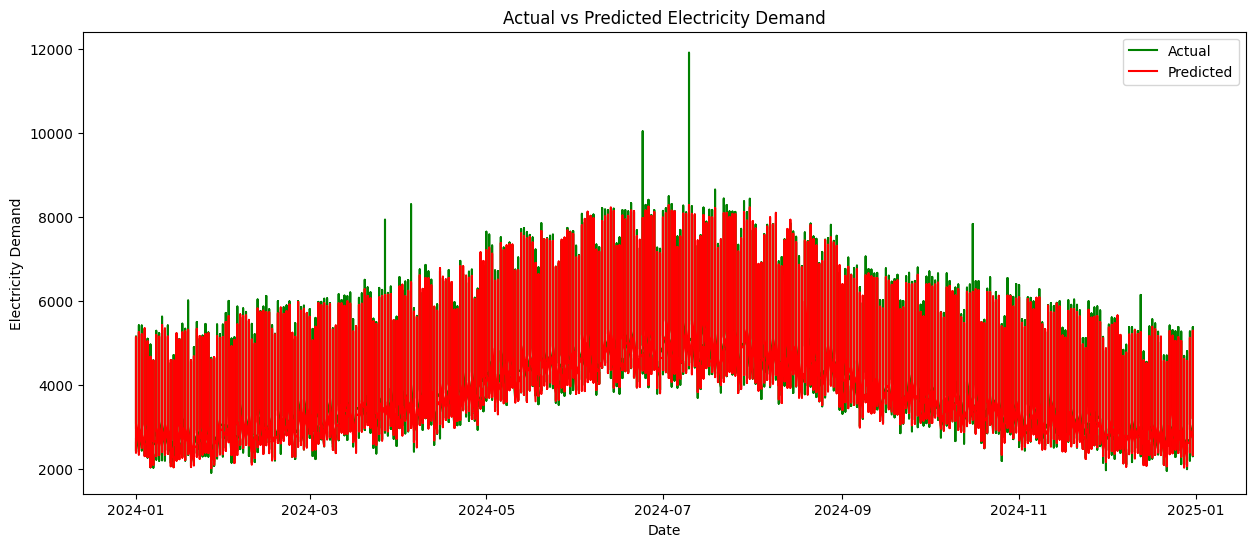

In [93]:
#visual
plt.figure(figsize=(15,6))
plt.plot(Y_test.index, Y_test.values, label='Actual', color='Green')
plt.plot(Y_test.index, predictions_xgb, label='Predicted', color='Red')
plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

In [94]:
import joblib
joblib.dump(model_xgb, 'Electricity Demand Forecasting_xgb.pkl')

['Electricity Demand Forecasting_xgb.pkl']